In [1]:
#In this part, the main libraries used in the project are imported.
#pandas is used for data manipulation and analysis,
#matplotlib and seaborn are used for data visualization,
#and plotly.express is used to create interactive and more advanced visualizations.
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
#In this step, Google Drive was mounted to the Colab notebook. This enabled direct access to datasets stored in Drive and allowed them to be used in the project.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
#In this step, all required datasets were loaded into separate DataFrames using the pandas library.
#Since the files use a semicolon (;) as a separator instead of a comma, the sep=';' parameter was specified.
#As a result, the orders, products, departments, aisles, and order_products tables were prepared for further analysis.
orders = pd.read_csv('/content/drive/MyDrive/instacart_orders.csv', sep=';')
products = pd.read_csv('/content/drive/MyDrive/products.csv', sep=';')
departments = pd.read_csv('/content/drive/MyDrive/departments.csv', sep=';')
aisles = pd.read_csv('/content/drive/MyDrive/aisles.csv', sep=';')
order_products = pd.read_csv('/content/drive/MyDrive/order_products.csv', sep=';')

This project uses the Instacart dataset, which consists of five related tables describing customer orders, products, and product categories. Together, these tables make it possible to analyze shopping behavior from multiple perspectives.

The orders table contains information about each order, including the customer, the day and hour of purchase, and the number of days since the previous order. The products table contains product-level information such as product name and its related aisle and department. The order_products table links products to orders and shows the order in which items were added to the cart, as well as whether the product had been purchased before. Finally, the aisles and departments tables provide category labels that help group products into broader sections.

Using these five tables together makes it possible to explore customer purchasing habits, reorder patterns, popular products, and cart-building behavior.

##Analysis of data

**In this step, an initial inspection of all datasets was performed. The .info() method was used to examine the structure of each table, including column names, data types, and missing values. The .head() method was used to display the first few rows, providing a quick overview of the data. This step was essential to understand the datasets before proceeding to data preprocessing.**

In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [5]:
orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [6]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [7]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [8]:
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [9]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [10]:
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [11]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [12]:
order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [13]:
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


## Find and Remove Missing Values

### `products` Data Frame

In [14]:
#In this step, missing values in the product_name column of the products dataset were examined.
#By filtering the data, only rows with missing product names were displayed, making it possible to identify where the issue occurs.
#This check is part of the data cleaning process.
products[products['product_name'].isna()]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


It was observed that all rows with missing product_name values might be associated with aisle_id = 100 and department_id = 21. To verify this, a check was performed to see whether these rows belong to any other aisles or departments. The goal was to determine whether the issue is isolated or more widespread.

In [15]:
#In this step, rows with missing product_name values were checked to see if any of them have an aisle_id different from 100.
#The purpose was to determine whether the issue is limited to aisle_id = 100 or exists in other categories as well.
#The result helps confirm whether the problem is isolated or widespread.
products[(products['product_name'].isna()) & (products['aisle_id'] != 100)]

,product_id,product_name,aisle_id,department_id


In [16]:
#The result shows that all rows with missing product_name values share the same aisle_id = 100 and department_id = 21.
#This indicates that the issue is not random but is limited to a specific category.
#In other words, the missing values are systematic and related to a particular group of data.

In [17]:
# Rows with missing product_name values were filtered to check if any belong to an aisle_id different from 21.
# The goal was to confirm whether missing values are limited to a specific category.
products[(products['product_name'].isna()) & (products['aisle_id'] != 21)]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


In [18]:
#The result shows that all rows with missing product_name belong to aisle_id = 100 and department_id = 21.
# This indicates that missing values are not random but concentrated in a specific category.

In [19]:
#In this step, the aisles dataset was filtered to find the row where aisle_id = 100.
# The purpose was to identify which category this aisle represents and better understand the source of missing product_name values.
aisles[aisles['aisle_id'] == 100]

,aisle_id,aisle
99,100,missing


In [20]:
#The result shows that aisle_id = 100 is labeled as “missing”.
# This indicates that the missing values in product_name are not actual missing data but are intentionally grouped under a “missing category” in the dataset.

In [21]:
# In this step, the departments dataset was filtered to find the row where department_id = 21.
# The purpose was to identify which category this department represents and better understand the source of missing product_name values.
departments[departments['department_id'] == 21]

,department_id,department
20,21,missing


In [22]:
# The result shows that department_id = 21 is labeled as “missing”.
# This indicates that rows with missing product_name are not actual products but are grouped under a “missing category” in the dataset.

In [23]:
# In this step, missing values in the product_name column of the products dataset were replaced with "Unknown".
# This was done to handle missing data and avoid issues in later analysis.
products['product_name'] = products['product_name'].fillna('Unknown')

### `orders` data frame

In [24]:
# In this step, rows with missing values in the days_since_prior_order column were filtered from the orders dataset.
# The goal was to examine where and under what conditions these missing values occur.
orders[orders['days_since_prior_order'].isna()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


In [25]:
# The result shows that all rows with missing days_since_prior_order have order_number = 1.
# This indicates that these are first-time orders, so there is no previous order to calculate the time difference.

In [26]:
# In this step, rows with missing days_since_prior_order values but with order_number not equal to 1 were filtered.
# The goal was to confirm whether missing values only occur in first orders.
orders[(orders['days_since_prior_order'].isna()) & (orders['order_number'] != 1)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


In [27]:
# No rows were found for this condition.
# This indicates that all missing values in days_since_prior_order belong only to order_number = 1, meaning first-time orders.

### `order_products` data frame

In [28]:
# In this step, rows with missing values in the add_to_cart_order column were filtered from the order_products dataset.
# The goal was to identify which orders contain these missing values.
order_products[order_products['add_to_cart_order'].isna()]

,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1
...,...,...,...,...
4505662,1800005,7411,NaN,0
4511400,1633337,260,NaN,0
4517562,404157,9517,NaN,0
4534112,1673227,17835,NaN,0


In [29]:
# Missing values were found in the add_to_cart_order column, affecting multiple orders.
# This indicates that the order in which items were added to the cart was not recorded for some products.

In [30]:
# In this step, the minimum and maximum values of the add_to_cart_order column were checked.
# The purpose was to understand the range of the item position in the cart and the overall spread of this variable.
order_products['add_to_cart_order'].min()

1.0

In [31]:
order_products['add_to_cart_order'].max()

64.0

In [32]:
# The result shows that the add_to_cart_order column ranges from 1 to 64.
# This indicates that the item position in each order starts at 1 and goes up to a maximum of 64 items.

In [33]:
# In this step, the order_id values from rows with missing add_to_cart_order were extracted and unique values were obtained.
# The goal was to identify which orders are affected by this issue.
missing_orders = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()

In [34]:
# In this step, orders listed in missing_orders were filtered from the order_products dataset. Then, the number of products per order_id was calculated, and the minimum number of items among these orders was determined.
# The goal was to understand the size of orders affected by missing values.
order_products[order_products['order_id'].isin(missing_orders)].groupby('order_id').size().min()

65

In [35]:
# The result shows that the minimum number of items in these orders is 65. This indicates that missing values in the add_to_cart_order column occur only in orders with more than 64 items.
# It suggests that the system only recorded the order position for the first 64 items, while the rest were left as NaN.

In [36]:
# In this step, missing values in the add_to_cart_order column were replaced with 999 and the column was converted to integer type.
# This approach ensures missing values are marked with a special code while maintaining a consistent data type for analysis.
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype(int)

## Finding and Removing Duplicate Values Across All Datasets

### `orders` data frame

In [37]:
# In this step, the number of duplicate rows in the orders dataset was calculated.
# The purpose was to identify how many repeated records exist in the data.
orders.duplicated().sum()

np.int64(15)

In [38]:
# The result shows that there are 15 duplicate rows in the orders dataset.
# This indicates a small number of repeated records that should be removed to ensure accurate analysis

In [39]:
# In this step, duplicate rows in the orders dataset were filtered and displayed.
# The goal was to visually inspect which specific rows are duplicated and understand their structure.
orders[orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


In [40]:
# In this step, duplicate rows were removed from the orders dataset.
# The index was then reset to start from zero using reset_index(drop=True), resulting in a cleaner and more consistent dataset.
orders = orders.drop_duplicates().reset_index(drop=True)

In [41]:
# In this step, the number of duplicate rows in the orders dataset was checked again.
# The goal was to confirm that all duplicates were successfully removed.
orders.duplicated().sum()

np.int64(0)

In [42]:
# The result shows that there are no duplicate rows left in the orders dataset (0).
# This confirms that all duplicates were successfully removed and the dataset is now clean.

### `products` data frame

In [43]:
# In this step, the number of duplicate rows in the products dataset was calculated.
# The goal was to check whether there are repeated product records in the dataset.
products.duplicated().sum()

np.int64(0)

In [44]:
# The result shows that there are no duplicate rows in the products dataset (0).
# This indicates that all product records are unique.

In [45]:
# In this step, duplicates in the products dataset were checked based only on the product_id column.
# The goal was to verify whether each product ID is unique.
products.duplicated(subset='product_id').sum()

np.int64(0)

In [46]:
# The result shows that there are no duplicate values based on product_id (0).
# This indicates that each product has a unique ID.

In [47]:
# In this step, the product_name column was converted to lowercase and checked for duplicate values.
# The goal was to ensure that product names are not duplicated due to differences in letter casing.
products['product_name'].str.lower().duplicated().sum()

np.int64(1361)

In [48]:
# The result shows that after converting product_name to lowercase, there are 1361 duplicate values.
# This indicates that the same product names can appear multiple times due to different formatting or casing.

In [49]:
# In this step, duplicate rows based on product_name were removed from the products dataset. Only the first occurrence of each product name was kept (keep='first), and the index was reset.
# The goal was to ensure that product names are unique in the dataset.
products = products.drop_duplicates(subset='product_name', keep='first').reset_index(drop=True)

### `departments` data frame

In [50]:
# In this step, duplicate rows in the departments dataset were filtered and displayed.
# The goal was to check whether there are repeated records in the departments table.
departments[departments.duplicated()]

,department_id,department


In [51]:
# The result shows that there are no duplicate rows in the departments dataset.
# This indicates that all department records are unique.

### `aisles` data frame

In [52]:
# In this step, the structure of the aisles dataset was inspected using the .info() method.
# Column names, data types, and potential missing values were reviewed.
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [53]:
# The result shows that the aisles dataset contains 134 rows and 2 columns (aisle_id, aisle).
# There are no missing values, and the data types are correct (int64, object).
# The dataset is clean and ready for analysis.

In [106]:
# In this step, the structure of the departments dataset was examined using the .info() method.
# Columns, data types, and the presence of missing values were reviewed.
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [55]:
# The result shows that the departments dataset contains 21 rows and 2 columns (department_id, department).
# There are no missing values, and the data types are correct.
#The dataset is clean and ready for use.

### `order_products` data frame

In [56]:
# In this step, duplicate rows in the order_products dataset were filtered and displayed.
# The goal was to check whether the same order–product records appear more than once.
order_products[order_products.duplicated()]

,order_id,product_id,add_to_cart_order,reordered


In [ ]:
# The result shows that there are no duplicate rows in the order_products dataset.
# This indicates that order–product records are unique.

### 1.1 Verification of order_hour_of_day and order_dow value ranges

In [57]:
# This code extracts all unique values from the order_hour_of_day column and sorts them in ascending order.
# The purpose is to verify that the hour values are within a valid range.
sorted(orders['order_hour_of_day'].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23)]

In [ ]:
# The result shows that order_hour_of_day values range from 0 to 23. This confirms that the data follows a valid 24-hour time format.

In [58]:
# This code extracts unique values from the order_dow column and sorts them in ascending order.
# The purpose is to verify whether the day-of-week values are within the expected range.
sorted(orders['order_dow'].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6)]

In [ ]:
# The result shows that order_dow values range from 0 to 6. This confirms that the days of the week are correctly encoded.

### 1.2 Analysis of what time of day people shop for groceries


In [59]:
# In this step, the number of orders for each hour in the order_hour_of_day column is calculated.
# The results are then sorted in ascending order to clearly show how orders are distributed throughout the day.
hour_counts = orders['order_hour_of_day'].value_counts().sort_index()

In [109]:
# In this step, the number of orders per hour of the day was visualized using a bar chart.
# The x-axis represents the hours of the day, and the y-axis shows the number of orders placed at each hour.
# The goal is to visually analyze shopping activity throughout the day.
fig = px.bar(x=hour_counts.index,y=hour_counts.values,labels={'x': 'Hour of Day', 'y': 'Number of Orders'},title='Number of Orders by Hour of Day')

fig.show()

In [ ]:
# The chart shows that most orders are placed during the middle of the day.
# The busiest period is approximately between 9:00 AM and 5:00 PM, with clear peaks around 10:00 AM and 3:00 PM.
# Order activity is much lower during late-night and early-morning hours.

### 1.3 Analysis of which days of the week people shop for groceries


In [61]:
# In this step, the number of orders for each value in the order_dow column was calculated and sorted in ascending order by day.
# The purpose is to identify on which days of the week people place more grocery orders.
dow_counts = orders['order_dow'].value_counts().sort_index()

In [62]:
# In this step, the number of orders by day of the week was visualized using a bar chart.
# The x-axis represents the days, while the y-axis shows the number of orders placed on each day.
# The goal is to visually identify which days of the week customers are most active in grocery shopping.
fig = px.bar(x=dow_counts.index,y=dow_counts.values,labels={'x': 'Day of Week (0=Sunday assumed)', 'y': 'Number of Orders'},title='Number of Orders by Day of Week')

fig.show()

In [ ]:
# The chart shows that the highest number of orders occurs on days labeled 0 and 1.
# Assuming 0 corresponds to Sunday, this suggests that people shop more at the beginning of the week.
# Order activity appears to decrease slightly in the middle of the week.

### 1.4 Analysis of how long customers wait before placing another order

In [63]:
# In this step, missing values in the days_since_prior_order column were removed because they correspond to first-time orders and do not represent a valid reorder interval.
# Then, the number of orders for each day gap was counted and sorted in ascending order to analyze how long customers wait before placing another order.
days_counts = (orders['days_since_prior_order'].dropna().value_counts().sort_index())

In [64]:
# In this step, the number of orders was visualized with a bar chart based on the number of days since the prior order.
# The x-axis represents the day gap, while the y-axis shows the number of orders for each interval.
# The goal is to visually understand how long customers typically wait before placing another order.
fig = px.bar(x=days_counts.index,y=days_counts.values,labels={'x': 'Days Since Prior Order', 'y': 'Number of Orders'},title='Distribution of Days Since Prior Order')

fig.show()

In [ ]:
#The chart shows that most customers place their next order within 2–10 days, with the strongest peak occurring at day 7.
# This suggests that weekly ordering behavior is very common.
# There is also a noticeable spike at 30 days, which may reflect monthly ordering habits or a limitation of the dataset where values above 30 are not separately recorded.

### 2.1 Comparison of order hour distributions on Wednesdays and Saturdays

In [65]:
# In this step, orders placed on Wednesday (order_dow = 3) and Saturday (order_dow = 6) were filtered into separate subsets.
# The purpose was to prepare the data for comparing order-hour patterns between these two days.
wednesday = orders[orders['order_dow'] == 3]
saturday = orders[orders['order_dow'] == 6]

In [66]:
# In this step, the number of orders placed at each hour of the day was calculated for both Wednesday and Saturday.
# The results were sorted by hour to make the comparison clearer and easier to interpret.
wednesday_counts = wednesday['order_hour_of_day'].value_counts().sort_index()
saturday_counts = saturday['order_hour_of_day'].value_counts().sort_index()

In [67]:
# In this step, the hourly order counts for Wednesday and Saturday were combined into a single DataFrame.
# Any missing values were replaced with 0 so that both days could be compared consistently in the same table.
comparison = pd.DataFrame({'Wednesday': wednesday_counts,'Saturday': saturday_counts}).fillna(0)

In [68]:
# In this step, the hourly order distributions for Wednesday and Saturday were visualized using a line chart.
# The chart makes it easier to directly compare shopping activity throughout the day and identify differences in peak ordering times.
fig = px.line(comparison,x=comparison.index,y=comparison.columns,labels={'x': 'Hour of Day', 'value': 'Number of Orders'},title='Order Hour Distribution: Wednesday vs Saturday')

fig.show()

In [ ]:
# The chart shows that the overall hourly distribution of orders on Wednesday and Saturday is fairly similar.
# On both days, order activity rises from the morning and reaches its peak around midday to early afternoon.
# However, there is a small dip on Wednesday between 11:00 and 13:00, while Saturday appears more stable during that period with a smoother flow of orders.

### 2.2 Analysis of the distribution of the number of orders per customer



In [69]:
# In this step, the number of orders was calculated for each user_id in the orders dataset.
# This produced a structure showing how many total orders each customer has placed.
orders_per_user = orders.groupby('user_id')['order_id'].count()

In [70]:
# In this step, the calculated order counts per customer were sorted in ascending order.
# This makes the distribution easier to inspect and prepares the data for clearer visualization.
orders_per_user = orders_per_user.sort_values()

In [71]:
# In this step, the distribution of the number of orders per customer was visualized using a histogram.
# The x-axis represents the number of orders, while the y-axis shows how many customers placed that number of orders.
# The goal is to understand the typical ordering behavior of customers.
fig = px.histogram(orders_per_user,nbins=20,title='Distribution of Number of Orders per Customer',labels={'value': 'Number of Orders', 'count': 'Number of Customers'})

fig.show()

In [ ]:
# The chart shows that most customers have placed only a small number of orders.
# The highest concentration appears in the 1–5 order range, and the number of customers decreases sharply as the number of orders increases.
# This suggests that low-frequency customers make up the majority of the dataset, while high-frequency customers are relatively rare.

### 2.3 Identification of the top 20 most popular products




In [72]:
# In this step, the order_products and products datasets were merged using the product_id column.
# The purpose was to connect order records with product names so that product popularity could be analyzed more clearly.
merged = order_products.merge(products, on='product_id')

In [73]:
# In this step, the number of times each product was ordered was calculated from the merged dataset.
# The results were sorted in descending order, and the top 20 most frequently ordered products were selected.
top_products = (merged.groupby(['product_id', 'product_name']).size().sort_values(ascending=False).head(20))

In [74]:
# In this step, the list of the top 20 most ordered products was displayed.
# This made it possible to directly view the most popular products by both product_id and product_name.
print(top_products)

product_id  product_name            
24852       Banana                      66050
13176       Bag of Organic Bananas      53297
21137       Organic Strawberries        37039
21903       Organic Baby Spinach        33971
47209       Organic Hass Avocado        29773
47766       Organic Avocado             24689
47626       Large Lemon                 21495
16797       Strawberries                20018
26209       Limes                       19690
27845       Organic Whole Milk          19600
27966       Organic Raspberries         19197
22935       Organic Yellow Onion        15898
24964       Organic Garlic              15292
45007       Organic Zucchini            14584
39275       Organic Blueberries         13879
49683       Cucumber Kirby              13675
28204       Organic Fuji Apple          12544
5876        Organic Lemon               12232
8277        Apple Honeycrisp Organic    11993
40706       Organic Grape Tomatoes      11781
dtype: int64


In [ ]:
# The result shows that most of the top 20 most ordered products are fresh produce items.
# Products such as bananas, organic bananas, strawberries, spinach, avocados, lemons, and milk appear at the top of the list.
# This suggests that customers mainly purchase fresh, everyday grocery essentials.

In [75]:
# In this step, the top_products result was converted into a DataFrame so it could be used for visualization.
# Then, a bar chart was created to display the top 20 most ordered products.
# The chart makes it easier to compare product names and their order counts.
top_df = top_products.reset_index(name='order_count')

fig = px.bar(top_df,x='product_name',y='order_count',title='Top 20 Most Popular Products')

fig.show()

In [ ]:
# The chart shows that bananas and organic bananas clearly stand out as the most popular products.
# Overall, most items in the top 20 are fresh produce and other everyday grocery essentials.
# This suggests that customers mainly prefer fresh and frequently purchased products.

### 3.1 Analysis of how many items people typically buy in one order and what the distribution looks like

In [76]:
# In this step, the number of products in each order_id was calculated.
# This produced a structure showing how many items each order contains.

items_per_order = order_products.groupby('order_id')['product_id'].count()

In [77]:
# In this step, the distribution of order sizes was calculated, meaning how many orders contain 1 item, 2 items, 3 items, and so on.
# The result was sorted in ascending order for easier visualization.

dist = items_per_order.value_counts().sort_index()

In [78]:
# In this step, the distribution of the number of items per order was visualized using a bar chart.
# The x-axis shows the number of items in an order, while the y-axis shows how many orders have that size.
# The goal is to visually examine how many products people typically buy in one order.

fig = px.bar(x=dist.index,y=dist.values,labels={'x': 'Number of Items in Order', 'y': 'Number of Orders'},title='Distribution of Items per Order')

fig.show()

In [ ]:
# The chart shows that most orders contain a relatively small number of items, and the distribution is right-skewed with a long tail.
# The most typical order size is around 5–6 items, and most orders fall within the 1–20 item range.
# Larger orders do exist, but they are much less common.

In [79]:
# In this step, only orders with fewer than 35 items were kept so that very large orders would not dominate the overall distribution.
# Then, the distribution of these filtered order sizes was calculated to make typical order patterns easier to observe.

filtered = items_per_order[items_per_order < 35]

filtered_dist = filtered.value_counts().sort_index()

In [80]:
# In this step, the distribution of orders with fewer than 35 items was visualized using a separate bar chart.
# The goal was to zoom in on the main part of the distribution and make it easier to see the most common order sizes.

fig = px.bar(x=filtered_dist.index,y=filtered_dist.values,labels={'x': 'Number of Items in Order (<35)', 'y': 'Number of Orders'},title='Distribution of Items per Order (Zoomed In)'
)

fig.show()

In [ ]:
# The zoomed-in chart shows that the most typical order size is around 5–6 items.
# Most orders are concentrated in the 1–20 item range, and the number of orders gradually declines beyond that point.
#This suggests that customers usually place small to medium-sized grocery orders.

### 3.2 Identification of the top 20 most frequently reordered items

In [81]:
# In this step, only reordered products were selected from the order_products dataset.
# Rows where reordered = 1 were filtered to create a separate dataset for analyzing products that were purchased again.

reordered = order_products[order_products['reordered'] == 1]

In [82]:
# In this step, the reordered dataset containing only reordered products was merged with the products dataset using the product_id column.
# The purpose was to connect product IDs with product names and make the reorder analysis easier to interpret.

merged = reordered.merge(products, on='product_id')

In [83]:
# In this step, the number of times each product was reordered was calculated.
# The results were sorted in descending order, and the top 20 most frequently reordered products were selected.

top_reordered = (merged.groupby(['product_id', 'product_name']).size().sort_values(ascending=False).head(20))

In [84]:
# In this step, the list of the top 20 most frequently reordered products was displayed.
# The output makes it possible to view both product IDs and product names together.

print(top_reordered)

product_id  product_name            
24852       Banana                      55763
13176       Bag of Organic Bananas      44450
21137       Organic Strawberries        28639
21903       Organic Baby Spinach        26233
47209       Organic Hass Avocado        23629
47766       Organic Avocado             18743
27845       Organic Whole Milk          16251
47626       Large Lemon                 15044
27966       Organic Raspberries         14748
16797       Strawberries                13945
26209       Limes                       13327
22935       Organic Yellow Onion        11145
24964       Organic Garlic              10411
45007       Organic Zucchini            10076
49683       Cucumber Kirby               9538
28204       Organic Fuji Apple           8989
8277        Apple Honeycrisp Organic     8836
39275       Organic Blueberries          8799
5876        Organic Lemon                8412
49235       Organic Half & Half          8389
dtype: int64


In [ ]:
# The result shows that most of the top reordered products are again fresh produce and everyday grocery items.
# Products such as bananas, organic bananas, strawberries, spinach, avocados, and dairy items appear at the top.
# This suggests that customers tend to reorder perishable and regularly used products more often.

In [85]:
# In this step, the top_reordered result was converted into a DataFrame so it could be used for visualization.
# Then, a bar chart was created to display the top 20 most frequently reordered products.
# The chart makes it easier to compare product names and their reorder counts.

top_df = top_reordered.reset_index(name='reorder_count')

fig = px.bar(top_df,x='product_name',y='reorder_count',title='Top 20 Most Reordered Products')

fig.show()

In [ ]:
# The chart shows that bananas and organic bananas clearly dominate the list of most reordered products.
# Overall, most items in the top 20 are fresh produce, dairy, and other everyday grocery essentials.
# This suggests that customers tend to reorder frequently used and quickly consumed products.

### 3.3 Determining the proportion of orders that are reorders for each product




In [86]:
# In this step, the order_products and products datasets were merged using the product_id column.
# The purpose was to connect order records with product names and create a suitable structure for calculating the reorder proportion of each product.

merged = order_products.merge(products, on='product_id')

In [87]:
# In this step, the order_products and products datasets were merged using the product_id column.
# The purpose was to connect order records with product names and create a suitable structure for calculating the reorder proportion of each product.

reorder_rate = (merged.groupby(['product_id', 'product_name'])['reordered'].mean().reset_index())

In [88]:
# In this step, products were sorted in descending order based on their reorder proportion.
# The goal was to highlight the products with the highest reorder rates.

reorder_rate = reorder_rate.sort_values('reordered', ascending=False)

In [89]:
# In this step, the top 20 products with the highest reorder proportion were displayed.
# The result includes each product’s product_id, product_name, and reordered rate.

reorder_rate.head(20)

,product_id,product_name,reordered
44530,49601,Pomegranate Gummy Bears,1.0
44583,49661,Porto,1.0
44579,49657,Cabernet Tomatoes,1.0
38582,42991,Kat Kit Disposable Tray,1.0
38597,43007,Breaded Chicken Breast Cutlets,1.0
2579,2867,Fruitwater Sparkling Lemon Lime,1.0
2584,2873,Vanilla Macadamia Milk,1.0
22149,24648,Irish Oatmeal,1.0
22152,24652,Dill Pickle Crunchy Popcorn,1.0
22153,24653,Premium Light Lager Beer,1.0


In [ ]:
# The result shows that the top 20 products all have a reordered value of 1.0.
# This means that every recorded order for those products in this dataset was marked as a reorder.
# However, this should be interpreted carefully, because some products may have only a small number of observations and still show a 100% reorder rate.
# In other words, a high proportion does not always mean high popularity; it may sometimes reflect limited data.

### 3.4 Determining the proportion of reordered products for each customer


In [90]:
# In this step, the order_products and orders datasets were merged using the order_id column.
# The goal was to connect product orders with the corresponding customers and create a suitable structure for analyzing reorder behavior by user.

merged = order_products.merge(orders, on='order_id')

In [91]:
# In this step, the mean of the reordered column was calculated for each user_id.
# Since reordered contains 0 and 1 values, this average represents the proportion of products ordered by each customer that were reorders.

customer_reorder = (merged.groupby('user_id')['reordered'].mean().reset_index())

In [92]:
# In this step, customers were sorted in descending order by their reorder proportion.
# The purpose was to highlight the customers with the highest reorder rates.

customer_reorder = customer_reorder.sort_values('reordered', ascending=False)

In [93]:
# In this step, the top 20 customers with the highest reorder proportion were displayed.
# The result shows that some users have a reordered value of 1.0.

customer_reorder.head(20)

,user_id,reordered
149589,206164,1.0
13072,17973,1.0
142827,196795,1.0
142825,196792,1.0
142824,196791,1.0
13127,18048,1.0
12980,17849,1.0
142802,196759,1.0
98293,135680,1.0
98685,136211,1.0


In [ ]:
# The result shows that some customers have a reorder rate of 1.0, meaning that all products ordered by these users in the dataset were marked as reorders.
# However, this should be interpreted carefully, since some customers may have ordered only a small number of products, which can make the rate appear artificially high.

In [111]:
# In this step, the distribution of customer reorder rates was visualized using a histogram.
# The x-axis shows each customer’s reorder rate, while the y-axis shows the number of customers with that rate.
#The goal was to better understand the overall pattern of reorder behavior at the customer level.

fig = px.histogram(customer_reorder,x='reordered',nbins=20,title='Distribution of Customer Reorder Rate',labels={'reordered': 'Reorder Rate', 'count': 'Number of Customers'}
)

fig.show()

In [ ]:
# The histogram shows that customer reorder behavior varies, with many users having a moderate-to-high reorder rate.
# The distribution spreads across the full 0 to 1 range, but there is noticeably greater concentration around 0.4–0.8.
# This suggests that a significant share of customers reorder a large portion of the products they buy.
# At the same time, the presence of values near both 0 and 1 indicates that customer behavior can be divided into different segments.

### 3.5 What are the top 20 items that people put in their carts first?




In [95]:
# In this step, the order_products and products datasets were merged using the product_id column.
# The purpose was to create a structure that allows the first-added cart items to be analyzed together with their product IDs and names.

merged = order_products.merge(products, on='product_id')

In [96]:
# In this step, only products that were added to the cart first were selected.
# Rows where add_to_cart_order = 1 were filtered to identify which products customers most often choose first.

first_items = merged[merged['add_to_cart_order'] == 1]

In [97]:
# In this step, the first-added cart items were counted, sorted in descending order, and the top 20 most frequent products were selected.
# The result shows how many times each product was the first item added to the cart.

top_first = (first_items.groupby(['product_id', 'product_name']).size().sort_values(ascending=False).head(20).reset_index(name='count'))

In [98]:
# In this step, the top 20 products most frequently added to the cart first were displayed.
# The output makes it possible to view the most common first-added items together with their product_id and product_name.

print(top_first)

    product_id                 product_name  count
0        24852                       Banana  15562
1        13176       Bag of Organic Bananas  11026
2        27845           Organic Whole Milk   4363
3        21137         Organic Strawberries   3946
4        47209         Organic Hass Avocado   3390
5        21903         Organic Baby Spinach   3336
6        47766              Organic Avocado   3044
7        19660                 Spring Water   2336
8        16797                 Strawberries   2308
9        27966          Organic Raspberries   2024
10       44632   Sparkling Water Grapefruit   1914
11       49235          Organic Half & Half   1797
12       47626                  Large Lemon   1737
13         196                         Soda   1733
14       38689     Organic Reduced Fat Milk   1397
15       26209                        Limes   1370
16       12341                Hass Avocados   1340
17        5785  Organic Reduced Fat 2% Milk   1310
18       27086                 

In [ ]:
# The result shows that the items most frequently added to the cart first are mainly fresh produce, dairy products, and beverages.
# Products such as bananas, organic bananas, milk, strawberries, avocados, and water stand out at the top.
# This suggests that customers often begin their shopping with everyday staple items.



In [99]:
# In this step, the top 20 products most frequently added to the cart first were visualized using a bar chart.
# The x-axis shows product names, while the y-axis represents how many times each product was the first item added to the cart.
# The goal was to visually compare which products customers most often start their shopping with.

fig = px.bar(top_first,x='product_name',y='count',title='Top 20 First Items Added to Cart')

fig.show()

In [ ]:
# The chart shows that bananas and organic bananas clearly dominate the list of first-added cart items.
# The rest of the list is mainly made up of dairy products, fresh produce, and beverages.
# This suggests that customers often begin their shopping with everyday staple items.

In [100]:
# In this step, descriptive statistics were calculated for the main numerical columns in the orders dataset.
# Using the describe() method, summary measures such as count, mean, standard deviation, minimum, maximum, and quartiles were obtained for each column.
# The goal was to statistically understand the distribution of order times and the number of days between orders.

orders[['order_hour_of_day', 'days_since_prior_order']].describe()

,order_hour_of_day,days_since_prior_order
count,478952.000000,450135.000000
mean,13.447034,11.101814
std,4.224567,9.190004
min,0.000000,0.000000
25%,10.000000,4.000000
50%,13.000000,7.000000
75%,16.000000,15.000000
max,23.000000,30.000000


In [ ]:
# The results show that the mean of order_hour_of_day is about 13.45, indicating that orders are generally placed around the middle of the day.
# The median of 13 supports this pattern. Since the minimum is 0 and the maximum is 23, orders occur across all hours of the day, but the standard deviation of 4.22 suggests that activity is concentrated in certain time periods.

# For days_since_prior_order, the average waiting time is about 11.1 days, while the median is 7 days.
# Since the median is lower than the mean, this suggests that many customers reorder after shorter intervals, while a smaller number of long gaps pull the average upward.
# The maximum value of 30 also indicates an upper limit in this column.

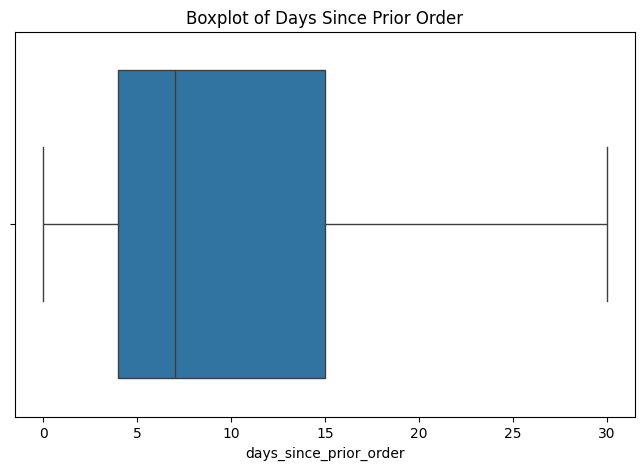

In [101]:
# In this step, the distribution of the days_since_prior_order column was visualized using a boxplot.
# The purpose was to examine the central tendency, spread, and possible outliers in the number of days between orders.

plt.figure(figsize=(8,5))
sns.boxplot(x=orders['days_since_prior_order'])
plt.title('Boxplot of Days Since Prior Order')
plt.show()

In [ ]:
# The boxplot shows that the main concentration of time gaps between orders falls roughly between 4 and 15 days, with a median around 7 days.
# This suggests that many users place their next order within about a week. The distribution is right-skewed, and the upper range extends to 30 days.
# There are no clear outliers visible, likely because the dataset is capped at a maximum value of 30 days.

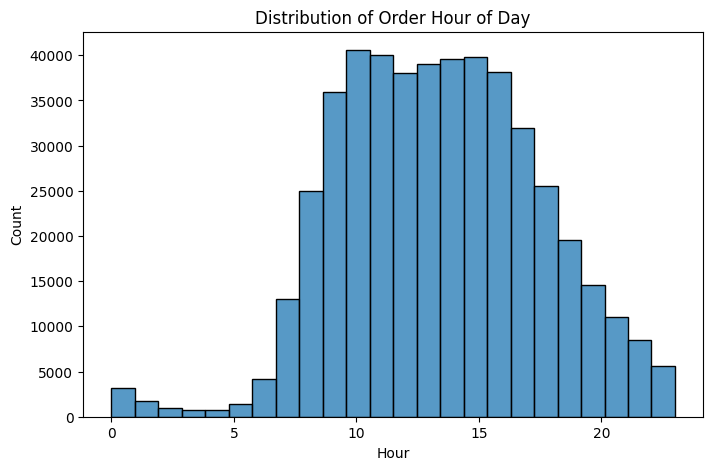

In [102]:
# In this step, the distribution of the order_hour_of_day column was visualized using a histogram.
# The purpose was to show more clearly at which hours of the day orders are most concentrated.

plt.figure(figsize=(8,5))
sns.histplot(orders['order_hour_of_day'], bins=24)
plt.title('Distribution of Order Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

In [ ]:
# The histogram shows that orders are concentrated mainly from the morning through the afternoon hours.
# Peak activity appears roughly between 10:00 and 15:00. Order volume is much lower during late-night and very early-morning hours.
# This is consistent with the earlier bar chart and confirms that customers mostly shop during the daytime.

In [103]:
# In this step, the mean and variance of the order_hour_of_day column were calculated.
# The mean shows the average time of day when orders are placed, while the variance helps measure how spread out the order times are.

print("Mean order hour:", orders['order_hour_of_day'].mean())
print("Variance order hour:", orders['order_hour_of_day'].var())

Mean order hour: 13.447034358349063
Variance order hour: 17.84696214769602


In [ ]:
# The results show that the mean order hour is approximately 13.45, meaning that orders are placed on average around the early afternoon.
#The variance of 17.85 indicates that order times are not concentrated at a single hour but are spread across different times of the day.
# Even so, as seen in the earlier charts, most activity is still concentrated around the middle of the day.

In [104]:
# In this step, the correlation between order_hour_of_day and days_since_prior_order was calculated.
# The purpose was to check whether there is any linear relationship between the time of day an order is placed and the number of days since the previous order.

print("Correlation:",orders['order_hour_of_day'].corr(orders['days_since_prior_order']))

Correlation: -0.0025091767563135115


In [ ]:
# The result shows a correlation of approximately -0.0025. Since this value is extremely close to 0, it indicates that there is virtually no linear relationship between these two variables.
# In other words, the time of day an order is placed does not appear to be related to how many days passed since the customer’s previous order.

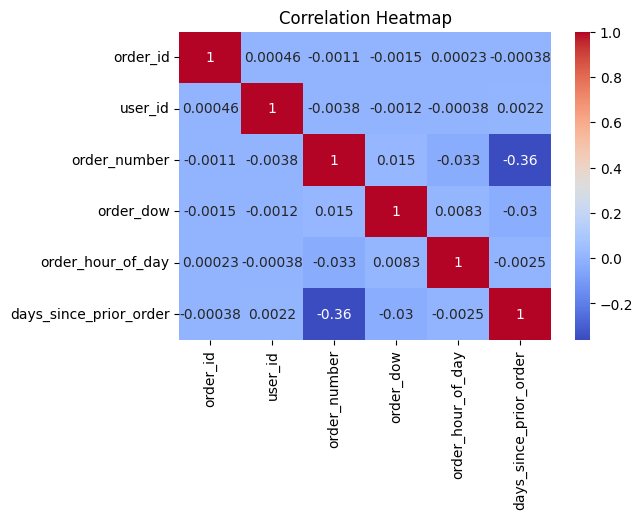

In [105]:
# In this step, the correlations between the numerical columns in the orders dataset were visualized using a heatmap.
# The goal was to identify whether the variables have positive, negative, or weak relationships.
# Since annot=True was used, each cell also displays the correlation coefficient value.

plt.figure(figsize=(6,4))
sns.heatmap(orders.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# The heatmap shows that most correlations between variables are very weak, with values close to 0.
# The most noticeable relationship is the negative correlation between order_number and days_since_prior_order (around -0.36).
# This suggests that as customers place more orders, the time gap between their orders tends to decrease somewhat.
# On the other hand, the correlation between order_hour_of_day and days_since_prior_order is nearly zero, meaning there is no meaningful relationship between the hour of the day and how long customers waited since their previous order.

**Conclusion**

This project explored Instacart customer shopping behavior through data cleaning, preprocessing, and exploratory data analysis. During preprocessing, missing values and duplicate records were identified and handled to ensure the dataset was suitable for analysis. After cleaning, the data revealed several clear behavioral patterns.

The analysis showed that grocery shopping activity is concentrated during the daytime, especially between late morning and afternoon hours, with peak order activity around 10 AM to 3 PM. Customers also appear to shop more frequently at the beginning of the week, suggesting that grocery ordering is often tied to weekly planning habits.

Another important finding is that many customers reorder products on a regular basis. The most reordered and most popular products are mainly fresh produce, dairy, and other everyday essentials. This indicates that Instacart is strongly used for routine grocery replenishment rather than only occasional or one-time purchases. In addition, most customers place relatively small or medium-sized orders, with a typical order containing around 5 to 6 items.

Overall, the results suggest that Instacart customers demonstrate structured and repetitive purchasing behavior. Their habits are shaped by time of day, weekly cycles, and repeated demand for staple items. These insights provide valuable direction for improving marketing strategies, recommendation systems, and customer retention efforts.

**Business Recommendations**

1. Improve personalized reorder recommendations

A large portion of customers repeatedly purchase the same products, especially fresh produce, dairy, and daily essentials. This suggests that Instacart should strengthen its personalized reorder system by making previously purchased items easier to access. Features such as “Buy Again” sections, one-click reorder options, and predicted weekly essentials could reduce friction and increase repeat purchases.

2. Use peak shopping hours for targeted marketing

The analysis showed that most orders are placed during the daytime, especially between 10 AM and 3 PM. This means Instacart can improve conversion rates by scheduling promotions, app notifications, and reminder messages during these peak activity hours. Time-based campaigns could be particularly effective for encouraging users to complete abandoned carts or respond to limited-time discounts.

3. Build strategies around weekly shopping cycles

Customer behavior strongly suggests a weekly reorder pattern, with a major spike around 7 days after the previous order. This indicates that many users follow a routine grocery cycle. Instacart could take advantage of this by sending timely reorder reminders, offering weekly grocery bundles, or introducing subscription-based essentials plans for frequently reordered products.

4. Promote staple products more aggressively

Products such as bananas, milk, avocados, strawberries, and other fresh items appear repeatedly among the most popular, most reordered, and first-added-to-cart items. These products are clearly central to customer shopping habits. Instacart should prioritize them in homepage recommendations, featured deals, and personalized product placements. Highlighting staple goods can make the shopping process more intuitive and may also increase basket completion rates.

5. Optimize the app for small and medium-sized orders

Most customers place orders containing around 5 to 6 items, and the majority of baskets are relatively small. This suggests that many customers use Instacart for quick and practical grocery replenishment rather than very large stock-up orders. To support this behavior, the platform could improve features such as quick cart creation, instant reorder baskets, simplified checkout, and mobile-first convenience tools.

6. Segment customers by reorder behavior

Not all customers behave the same way. Some have very high reorder rates, while others reorder much less frequently. This creates an opportunity for segmentation. High-reorder customers may respond well to loyalty programs, premium membership offers, or subscription incentives, while lower-reorder customers may benefit more from discounts, onboarding campaigns, and personalized discovery recommendations.

7. Strengthen retention strategies for routine shoppers

Since the data suggests that many customers use Instacart as part of a routine shopping habit, Instacart should treat these users as high-value long-term customers. Features such as habit-based reminders, recurring shopping lists, and automatic refill suggestions could reinforce customer loyalty and reduce the chance of users switching to competitors.

8. Use first-added cart items to improve product placement

The products most frequently added first to the cart are often produce, dairy, and beverages. This suggests these products may play an important role in how customers begin their shopping journey. Instacart can use this behavior to improve app design by placing these items in more visible positions, using them as part of personalized landing pages, or designing smarter recommendation flows based on “first-item intent.”

9. Design promotions around essential and perishable goods

Because the most reordered items are often perishable essentials, Instacart should consider promotions tailored around these categories. For example, the platform could create fresh produce bundles, dairy refill discounts, or “weekly essentials” promotions. These are likely to feel highly relevant to customers and could drive both purchase frequency and basket size.

10. Support long-term customer value with predictive analytics

The observed regularity in customer ordering behavior creates strong potential for predictive modeling. Instacart could use customer history to anticipate when users are likely to reorder and what they are most likely to need. This would allow the company to move from reactive recommendations to proactive shopping assistance, improving user convenience and overall retention.